<a href="https://colab.research.google.com/github/SyedAliRizve110/House-Price-Prediction-System/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

Importing the Boston House Price datase

In [2]:
house_price = sklearn.datasets.fetch_california_housing
house_price_dataset = house_price()

In [3]:
print(house_price_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [4]:
# Loading the dataset to a Pandas Dataframe
house_price_dataframe =pd.DataFrame(house_price_dataset.data, columns= house_price_dataset.feature_names)

In [5]:
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
# add the target (price) column to the dataFrame
house_price_dataframe['price'] = house_price_dataset.target

In [7]:
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
# checking no. of rows and columns in the data frame
house_price_dataframe.shape

(20640, 9)

In [9]:
# check for missing values
house_price_dataframe.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


In [10]:
# statistical measures of the dataset
house_price_dataframe.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Understanding the correlation between various features in the dataset

1) Positive Correlation
2) Negative Correlation

In [11]:
correlation = house_price_dataframe.corr()

<Axes: >

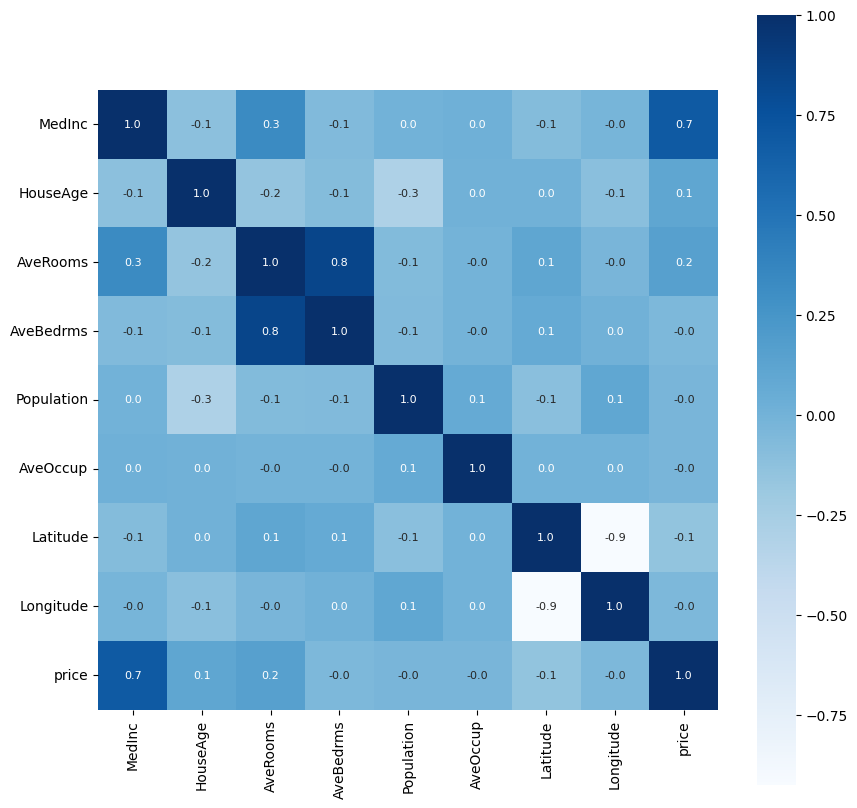

In [12]:
# constructing heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar = True, square= True, fmt ='.1f', annot= True, annot_kws= {'size':8}, cmap= 'Blues')

Data Visualization

In [13]:
house_price_dataframe.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'price'],
      dtype='object')

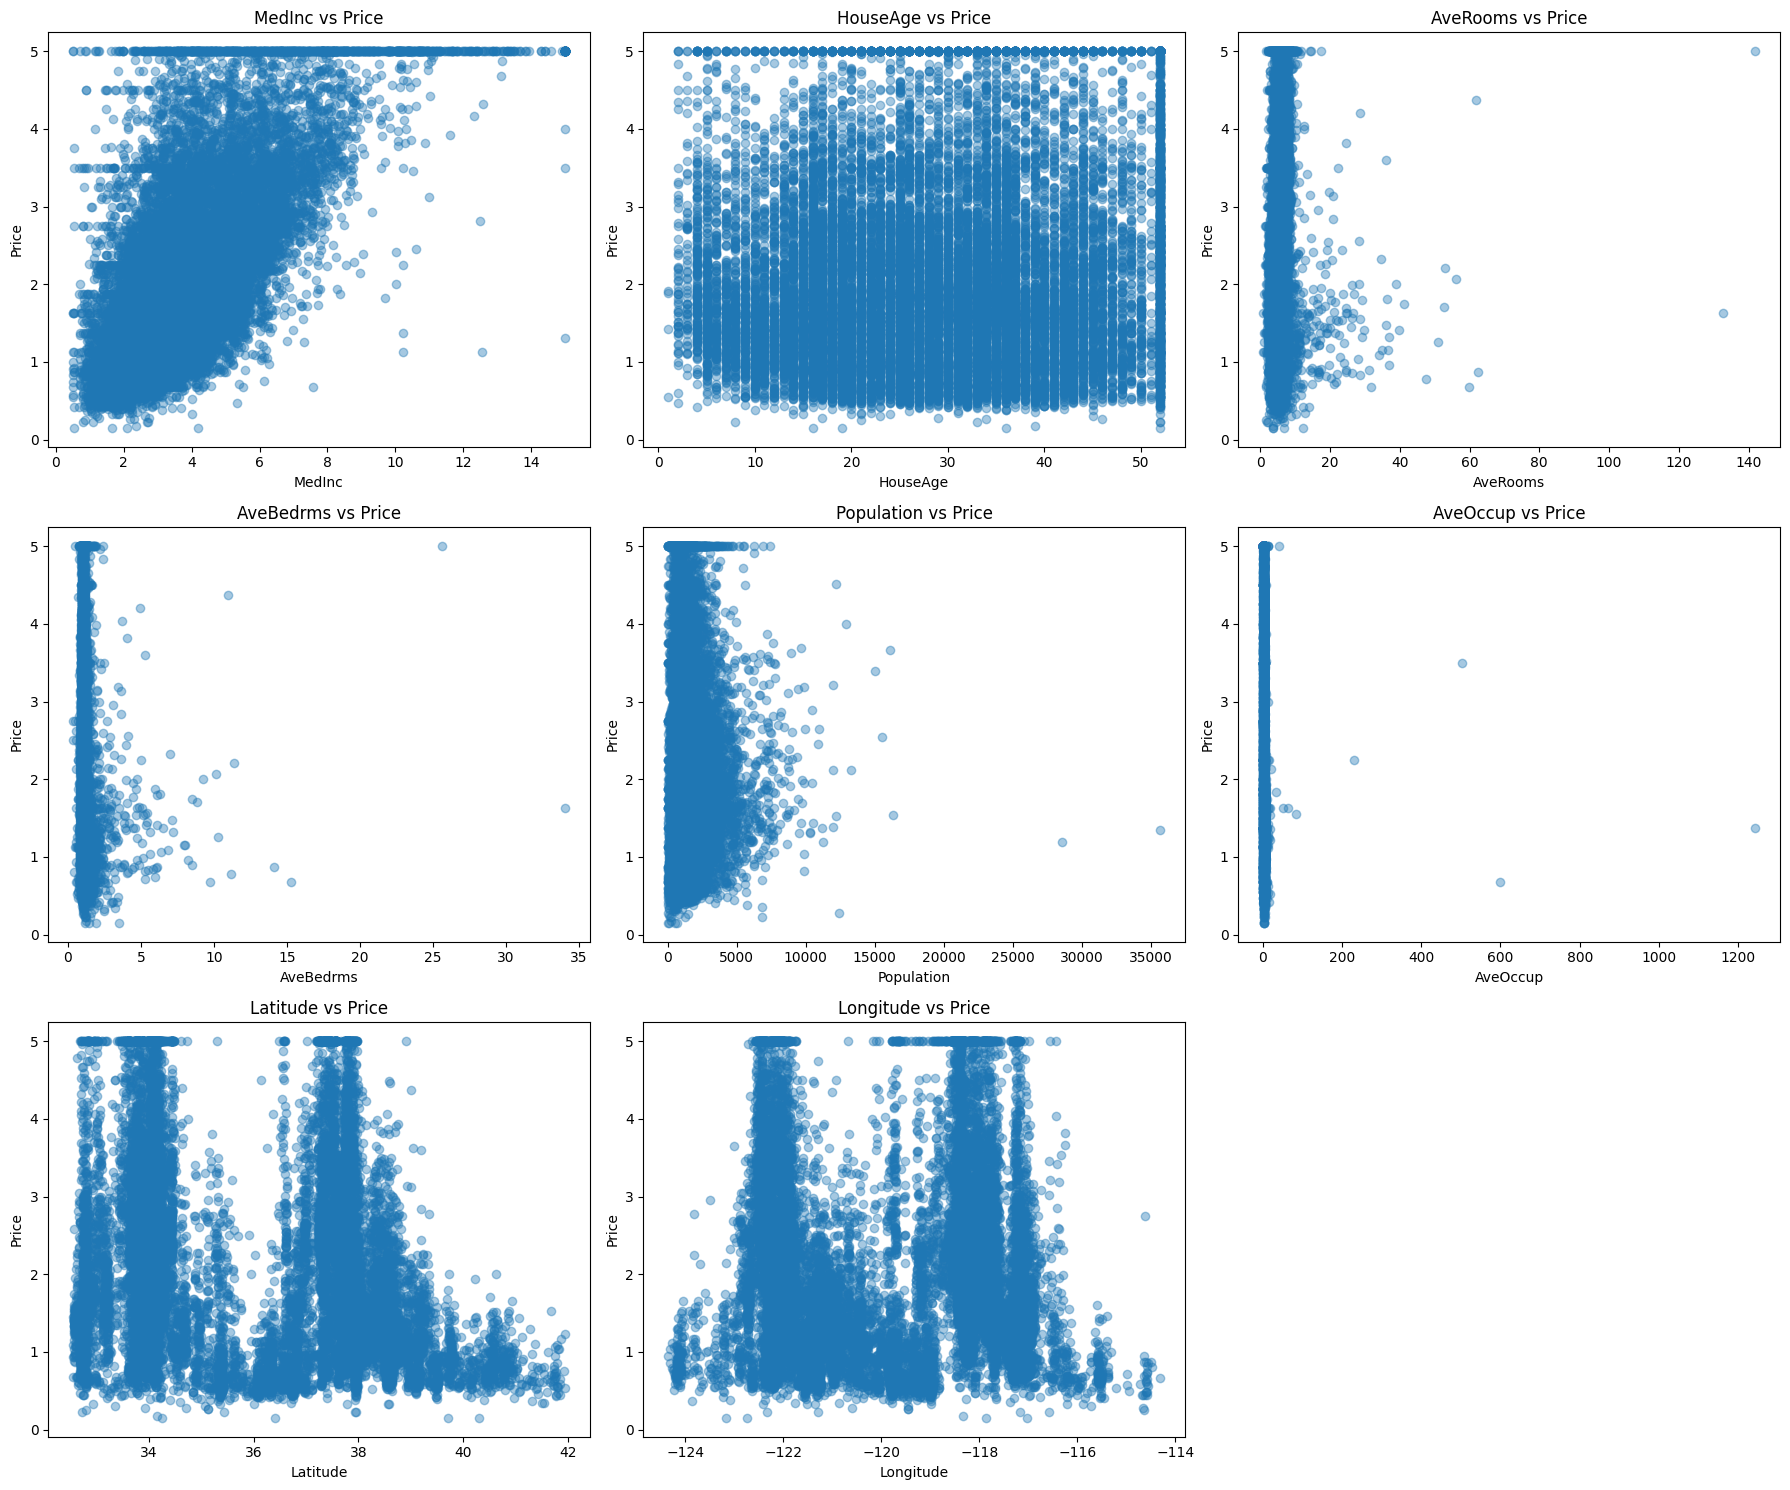

In [14]:
# Scatter Plot of Every Feature vs Price
features = [
        'MedInc','HouseAge','AveRooms','AveBedrms','Population', 'AveOccup','Latitude','Longitude'
]

plt.figure(figsize=(18,15))

for i, feature in enumerate(features):
  plt.subplot(3,3,i+1)
  plt.scatter(
    house_price_dataframe[feature],
    house_price_dataframe['price'],
    alpha =0.4
  )
  plt.xlabel(feature)
  plt.ylabel("Price")
  plt.title(f"{feature} vs Price")


plt.tight_layout()
plt.show()


Text(0, 0.5, 'Frequency')

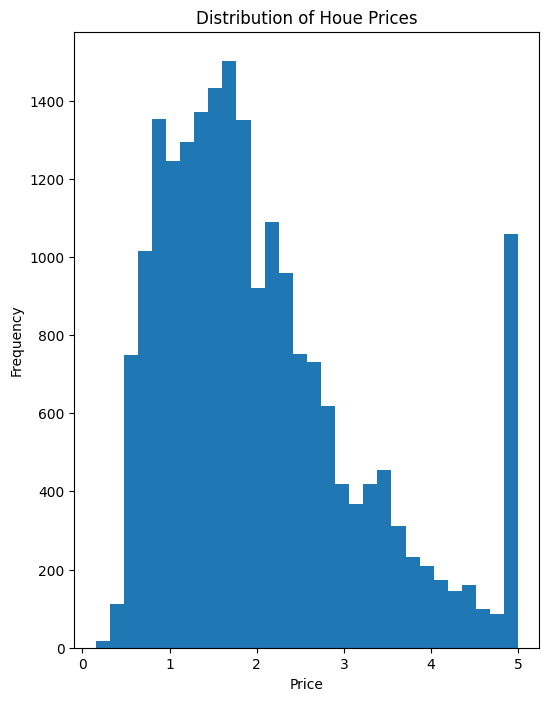

In [15]:
# Distribution of House Prices
plt.figure(figsize=(6,8))

plt.hist(
    house_price_dataframe['price'],
    bins = 30
)

plt.title("Distribution of Houe Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

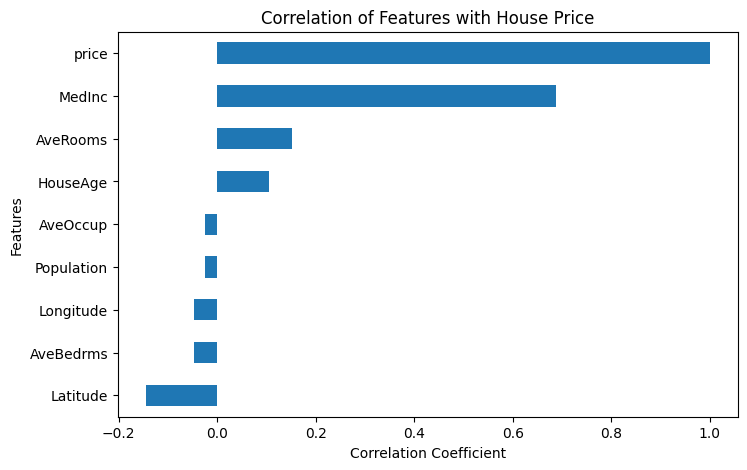

In [16]:
# Correlation with Price
correlation = house_price_dataframe.corr()['price'].sort_values()

plt.figure(figsize=(8,5))

correlation.plot(
    kind='barh'
)

plt.title("Correlation of Features with House Price")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.show()

Splitting the data and Target

In [17]:
X = house_price_dataframe.drop(['price'], axis = 1)
Y = house_price_dataframe['price']

In [18]:
print(X)
print(Y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

Splitting the data into training data and test data

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [20]:
print(X.shape, X_train.shape, X_test.shape)

(20640, 8) (16512, 8) (4128, 8)


Model Training

XGBoost Refressor

In [21]:
# Loading the mode
model = XGBRegressor()

In [22]:
# training the model with X_train

model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation

Prediction on training data

In [23]:
# accuracy for prediction on training data
training_data_prediction = model.predict(X_train)

In [24]:
print(training_data_prediction)

[0.53758794 2.9007688  0.6848911  ... 1.7890452  1.9554564  0.7771621 ]


In [25]:
# R squared error
score_1 = metrics.r2_score(Y_train, training_data_prediction)


# Mean absolute error
score_2 =metrics.mean_absolute_error(Y_train, training_data_prediction)

print("R squared error:", score_1)
print("Mean Absolute Error", score_2)

R squared error: 0.947186443380359
Mean Absolute Error 0.18885009247854148


Visualizing the actual Prices and Predicted Prices

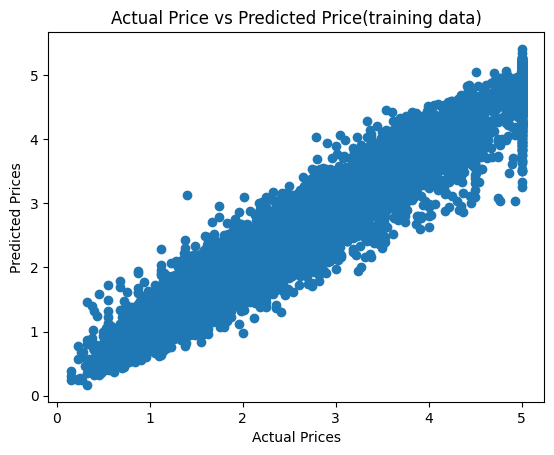

In [26]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title("Actual Price vs Predicted Price(training data)")
plt.show()

Prediction on Test Data

In [27]:
test_data_prediction = model.predict(X_test)

In [28]:
print(test_data_prediction)

[2.880331   1.8918151  0.923897   ... 1.5574043  0.82967275 1.9735563 ]


Prediction Accuracy

In [29]:
# R squared error
score_1 = metrics.r2_score(Y_test, test_data_prediction)


# Mean absolute error
score_2 =metrics.mean_absolute_error(Y_test, test_data_prediction)

print("R squared error:", score_1)
print("Mean Absolute Error", score_2)

R squared error: 0.8370813165448978
Mean Absolute Error 0.3079223702763229


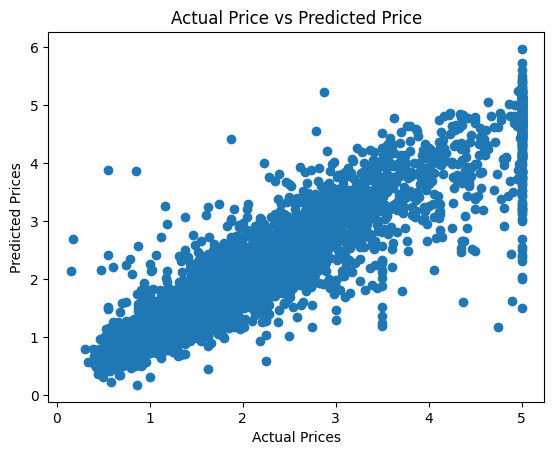

In [30]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title("Actual Price vs Predicted Price")
plt.show()